<a href="https://colab.research.google.com/github/Naylet92/Estudio_ambiental/blob/main/Colima/NCL_NDVI_Graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARCO GEOESPACIAL

## Área Natural Protegida: Parque Estatal Bosque Mesofilo Nevado de Colima

**Tesista:** Naylet Hernández Sánchez  
**Director:** Viacheslav Shalisko  
**Doctorado:** Geografía y Ordenamiento Territorial  
**Proyecto:** "Evaluación comparativa de la pérdida de hábitat en territorios protegidos y no protegidos de Jalisco mediante percepción remota y aprendizaje automatizado en el periodo 2000-2020".

## Prototipo de script para visualización de la dinamica anual de variables (NDVI, componentes de Tasseled Cap, etc.) en areas de interes

### Definicion de Variables

In [1]:
#  DEFINICIÓN DE VARIABLES

# Prefijo del área
PREFIJO     = 'NCL'

# Nombre del área
NOMBRE      = 'Nevado_Colima'

# Carpeta con capas de datos de entrada (modificar según sus ajustes de sistema)
#RUTA_GPKG  = '/content/drive/MyDrive/ANP/ParqueEstatalBosqueMesofiloNevadodeColima.gpkg'
RUTA_GPKG  = '/content/drive/MyDrive/Colab Data/Naylet/gpkg/ParqueEstatalBosqueMesofiloNevadodeColima.gpkg'
LAYER_NAME  = None

# Carpeta de salida en Drive (modificar según sus ajustes de sistema)
#RUTA_AOI    = '/content/drive/MyDrive/ANP/AOI'
RUTA_AOI    = '/content/drive/MyDrive/Colab Data/Naylet/AOI'

# Rutas derivadas automáticamente (no tocar)
RUTA_ANP= f'{RUTA_AOI}/aoi_{PREFIJO}.geojson'
RUTA_BBOX   = f'{RUTA_AOI}/{PREFIJO}_bbox.geojson'

# CRS geográfico y UTM
CRS_GEO     = 4326
CRS_UTM     = 32613

# Proyecto de Google Earth Engine (modificar según sus ajustes de sistema)
#GEE_PROJECT = 'ee-nayleths'
GEE_PROJECT = 'ee-vshalisko'

# Define el radio del círculo para muestreo de datos en metros (por ejemplo, 100 m)
radio_metros = 100

# Zoom inicial del mapa
ZOOM        = 12

# Estilo del área de estudio
STYLE_AREA  = {'color': 'blue', 'fillColor': '#0000ff30', 'weight': 1.5}

# Estilo del rectángulo rojo (bounding box)
STYLE_BBOX  = {'color': 'red', 'fillColor': '#00000000', 'weight': 2.5}

# Título del mapa
MAP_TITLE   = 'Área de estudio Nevado de Colima'

# Fechas de inicio y final de analisis
start_date = '2000-01-01'
end_date = '2020-12-31'

# Periodos (para cada periodo se genera una grafica del promedio)
periods = {
    '2000-2004': ('2000-01-01', '2004-12-31'),
    '2005-2009': ('2005-01-01', '2009-12-31'),
    '2010-2014': ('2010-01-01', '2014-12-31'),
    '2015-2020': ('2015-01-01', '2020-12-31')
}

# Colecciones Landsat a considerar
COLECCION_L5    = 'LANDSAT/LT05/C02/T1_L2'
COLECCION_L7    = 'LANDSAT/LE07/C02/T1_L2'
COLECCION_L8    = 'LANDSAT/LC08/C02/T1_L2'

# Bandas L5 y L7
BANDAS_SR       = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
BANDAS_CORR     = [b + '_corr' for b in BANDAS_SR]

# Bandas L8 y L9 (distinto orden: B2-B7 sin B6)
BANDAS_SR_L8    = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
BANDAS_CORR_L8  = [b + '_corr' for b in BANDAS_SR_L8]

# Coeficientes Tasseled Cap L7 (mismos que L5)
#TC_BRIGHT  = [0.3561, 0.3972, 0.3904, 0.6966, 0.2286, 0.1596]
#TC_GREEN   = [-0.3344, -0.3544, -0.4556, 0.6966, -0.0242, -0.2630]
#TC_WET     = [0.2626, 0.2141, 0.0926, 0.0656, -0.7629, -0.5388]

# Coeficientes Tasseled Cap L8
#TC_BRIGHT_L8 = [0.3029, 0.2786, 0.4733, 0.5599, 0.5082, 0.1872]
#TC_GREEN_L8  = [-0.2941, -0.2430, 0.5421, 0.2410, -0.5312, -0.3826]
#TC_WET_L8    = [0.1511, 0.1973, 0.3283, 0.3407, -0.7117, 0.4559]




In [2]:
import ee
import geemap
from google.colab import drive

import os
import math
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box, Point
from IPython.display import display, HTML

# Montar Google Drive
drive.mount('/content/drive')

# Autenticar e inicializar GEE
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print("✓ Entorno listo")

Mounted at /content/drive
✓ Entorno listo


### Cargar poligonos de la region (BBOX y limite ANP)

In [3]:
gdf_bbox = gpd.read_file(RUTA_BBOX)
geojson_bbox_str = gdf_bbox.to_crs(epsg=CRS_GEO).to_json()
region = ee.FeatureCollection(json.loads(geojson_bbox_str)).geometry()

gdf_anp = gpd.read_file(RUTA_ANP)
geojson_anp_str = gdf_anp.to_crs(epsg=CRS_GEO).to_json()
anp = ee.FeatureCollection(json.loads(geojson_anp_str)).geometry()

# FIX: calcular centroide en CRS proyectado, luego volver a geograficas
centroid_proj = gdf_bbox.to_crs(epsg=CRS_UTM).dissolve().centroid.iloc[0]
centroid = gpd.GeoSeries([centroid_proj], crs=CRS_UTM).to_crs(epsg=CRS_GEO).iloc[0]

### Definir puntos de muestreo

In [4]:
# puntos muestreo

# Data source
puntos_josn = {
    "Identificador": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Clase": ['BTC', 'BTC', 'BQP', 'BQP', 'BP', 'BP', 'BA', 'BA', 'BMM', 'BMM', 'Past'],
    "Latitud": [19.587936, 19.586346, 19.571679, 19.5806321, 19.5821993, 19.572845, 19.5822660, 19.532524, 19.5203311, 19.5643138, 19.5670833],
    "Longitud": [-103.698989, -103.530473, -103.524983, -103.5444625, -103.6177868, -103.638818, -103.5855996, -103.590116, -103.5655309, -103.5544415, -103.6049937]
}

# Load into a DataFrame
puntos_df = pd.DataFrame(puntos_josn)
display(puntos_df)

,Identificador,Clase,Latitud,Longitud
0,1,BTC,19.587936,-103.698989
1,2,BTC,19.586346,-103.530473
2,3,BQP,19.571679,-103.524983
3,4,BQP,19.580632,-103.544462
4,5,BP,19.582199,-103.617787
5,6,BP,19.572845,-103.638818
6,7,BA,19.582266,-103.585600
7,8,BA,19.532524,-103.590116
8,9,BMM,19.520331,-103.565531
9,10,BMM,19.564314,-103.554441


### Convertir puntos a circulos de muestreo

In [5]:
# Convertir puntos_df a un GeoDataFrame
puntos_gdf = gpd.GeoDataFrame(
    puntos_df,
    geometry=gpd.points_from_xy(puntos_df.Longitud, puntos_df.Latitud),
    crs=CRS_GEO
)

# Reproyectar a UTM para aplicar el buffer en metros
puntos_gdf_utm = puntos_gdf.to_crs(epsg=CRS_UTM)

# Aplicar el buffer a cada punto para crear círculos
circulos_gdf_utm = puntos_gdf_utm.copy()
circulos_gdf_utm['geometry'] = puntos_gdf_utm.geometry.buffer(radio_metros)

# Reproyectar los círculos de nuevo a WGS84
circulos_gdf_geo = circulos_gdf_utm.to_crs(epsg=CRS_GEO)

# Convertir el GeoDataFrame de círculos a una FeatureCollection de Earth Engine
circulos_fc_ee = ee.FeatureCollection(json.loads(circulos_gdf_geo.to_json()))

print(f"Se ha generado una capa de {len(puntos_df)} círculos con radio de {radio_metros} metros cada uno.")


Se ha generado una capa de 11 círculos con radio de 100 metros cada uno.


### Visualizar los circulos y areas en mapa

In [ ]:
# Estilo del área de estudio
STYLE_AREA  = {'color': 'blue', 'fillColor': '#0000ff30', 'weight': 1.5}

# Estilo del rectángulo rojo (bounding box)
STYLE_BBOX  = {'color': 'red', 'fillColor': '#00000000', 'weight': 2.5}

# Estilo del circulos de muestreo
STYLE_CIRCLES_MUESTREO = {'color': 'orange', 'fillColor': '#FFA50030', 'weight': 1.5}

mapa = geemap.Map(center=[centroid.y, centroid.x], zoom=ZOOM)

# Agregar área de estudio
mapa.add_gdf(gdf_anp, layer_name=MAP_TITLE, style=STYLE_AREA)

# Agregar rectángulo rojo (bounding box)
mapa.add_gdf(gdf_bbox, layer_name='Rectangulo delimitador', style=STYLE_BBOX)

# Visualizar los círculos de muestreo
mapa.addLayer(
    circulos_fc_ee,
    vis_params=STYLE_CIRCLES_MUESTREO,
    name='Círculos de muestreo'
)

# Agregar etiquetas para los circulos
mapa.add_labels(
    data=circulos_fc_ee,
    column="Identificador",
    font_size="12pt",
    font_color="black",
    font_family="arial",
    font_weight="normal"
)

# Mostrar el mapa
mapa

## Seleccionar datos Landsat (L5, L7, L8) y preprocesarlos, calcular NDVI

In [7]:
## funciones auxiliares para corrección de imagenes

# Enmascarar nubes Landsat (L5, L7 y L8)
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_mask = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_mask        = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud_shadow_mask.And(cloud_mask))

#  Corrección topográfica Landsat (L5, L7 y L8)
def correccion_topografica(image, region, bandas_sr, bandas_corr):
    dem        = ee.Image('USGS/SRTMGL1_003').clip(region)
    terreno    = ee.Terrain.products(dem)
    pendiente   = terreno.select('slope').multiply(math.pi / 180)
    orientacion = terreno.select('aspect').multiply(math.pi / 180)
    az_solar   = ee.Number(image.get('SUN_AZIMUTH')).multiply(math.pi / 180)
    elev_solar = ee.Number(image.get('SUN_ELEVATION')).multiply(math.pi / 180)
    cos_i = (
        pendiente.cos().multiply(elev_solar.sin())
        .add(pendiente.sin()
             .multiply(elev_solar.cos())
             .multiply(orientacion.subtract(az_solar).cos()))
    )

    ## para los valores de cos muy bajos tomamos 0.1 en su lugar
    cos_i_safe  = cos_i.max(0.1)
    cos_i_stack = cos_i_safe.rename('cos_i')

    ## aplicamos corrección para cada banda optica previamente reescalada
    ## con los factores de escala de manual de GEE para L5, L7, L8
    bandas_corr_img = (
        ee.Image.cat([
            image.select(b).multiply(0.0000275).add(-0.2)
                  .divide(cos_i_stack).rename(bandas_corr[i])
            for i, b in enumerate(bandas_sr)
        ])
        .set('SUN_AZIMUTH',   image.get('SUN_AZIMUTH'))
        .set('SUN_ELEVATION', image.get('SUN_ELEVATION'))
        .set('DATE_ACQUIRED',   image.get('DATE_ACQUIRED'))
        .cast({b: 'double' for b in bandas_corr})
    )
    ## para mantener valor de fecha se copia time_start
    return bandas_corr_img.copyProperties(image, ['system:time_start'])

In [8]:
# Funciones auxiliares para calculo de NDVI (según sistema), seleccion y
# pre-procesamiento de los conjunots de imagenes

#  Calcular NDVI para L5 y L7
def calcular_ndvi_l7(collection):
    return collection.map(lambda image: image.addBands(
        image.normalizedDifference(['SR_B4_corr', 'SR_B3_corr']).rename('NDVI')
    ))

#  Calcular NDVI para L8 y L9
def calcular_ndvi_l8(collection):
    return collection.map(lambda image: image.addBands(
        image.normalizedDifference(['SR_B5_corr', 'SR_B4_corr']).rename('NDVI')
    ))


def cargar_datos_landsat(geometry, start_date, end_date):
  ## Funcion para procesamiento de conjuntos Landsat en zona
  ## definida por geometry y en rango de fechas

    ## Procesar L5 (aplicar mascara de nubes y normlizacion topografica)
    col_ls5 = (ee.ImageCollection(COLECCION_L5)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls5 = col_ls5.size().getInfo()
    print(f"  Imágenes Landsat 5 diponibles: {n_ls5}")
    col_ls5_corr = None
    ndvi_l5 = None
    if n_ls5 > 0:
        #for f in sorted(col_ls5.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L5 {f}")
        col_ls5_corr = (col_ls5.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR, BANDAS_CORR))
                              .select(BANDAS_CORR))
        ndvi_l5 = calcular_ndvi_l7(col_ls5_corr)
    else:
        print("    Sin imágenes L5")

    ## Procesar L7 (aplicar mascara de nubes y normlizacion topografica)
    col_ls7 = (ee.ImageCollection(COLECCION_L7)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls7 = col_ls7.size().getInfo()
    print(f"  Imágenes Landsat 7 disponibles: {n_ls7}")
    col_ls7_corr = None
    ndvi_l7 = None
    if n_ls7 > 0:
        #for f in sorted(col_ls7.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L7 {f}")
        col_ls7_corr = (col_ls7.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR, BANDAS_CORR))
                              .select(BANDAS_CORR))
        ndvi_l7 = calcular_ndvi_l7(col_ls7_corr)
    else:
        print("    Sin imágenes L7")

    col_ls8 = (ee.ImageCollection(COLECCION_L8)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls8 = col_ls8.size().getInfo()
    print(f"  Imágenes Landsat 8 disponibles: {n_ls8}")
    col_ls8_corr = None
    ndvi_l8 = None
    if n_ls8 > 0:
        #for f in sorted(col_ls8.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L8 {f}")
        col_ls8_corr = (col_ls8.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR_L8, BANDAS_CORR_L8))
                              .select(BANDAS_CORR_L8))
        ndvi_l8 = calcular_ndvi_l8(col_ls8_corr)
    else:
        print("    Sin imágenes L8")

    # funcion regresa tres colecciones para capas corregidas y tres colecciones para NDVI
    return col_ls5_corr, col_ls7_corr, col_ls8_corr, ndvi_l5, ndvi_l7, ndvi_l8

def combinar_colecciones_ndvi(landsat_corr_ic):
        ## funcion para combinar imageCollections de distintos conjuntos
        #print(landsat_corr_ic)
        ## compilar una colección completa de L5, L7, L8
        if landsat_corr_ic[3] is not None:
            ndvi_merged = landsat_corr_ic[3]
            if landsat_corr_ic[4] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[4])
            if landsat_corr_ic[5] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[5])
        elif landsat_corr_ic[4] is not None:
            ndvi_merged = landsat_corr_ic[4]
            if landsat_corr_ic[5] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[5])
        elif landsat_corr_ic[5] is not None:
            ndvi_merged = landsat_corr_ic[5]
        else:
            print("No se encontraron imágenes Landsat para el período especificado.")
            return None
        return ndvi_merged

def medianas_por_periodo(geometry, periods, variable):
    ## funcion calcula capas de las medianas de variable geoespacial por periodo
    ## geometri permite seleccionar imagenes aplicables, pero no se usa para recortar
    medianas = {}
    for nombre, (inicio, fin) in periods.items():
        print(f'Calculo de medianas {variable} en periodo de {inicio} hasta {fin}')
        landsat_corr_ic = cargar_datos_landsat(geometry, start_date=inicio, end_date=fin)
        ndvi_combinado = combinar_colecciones_ndvi(landsat_corr_ic)
        ndvi_filtrado = ndvi_combinado.select(variable)
        mediana = ndvi_filtrado.median()
        #mediana = mediana.clip(geometry)
        medianas[nombre] = mediana
    ## funcion regtrase diccionario de periodos y objetos ee.image.Image
    ## que contienen los promedios de variable elegida
    return medianas


def calcular_intervalos_confianza(df, error_multiplier=1.96):
    """
    Calcula los intervalos de confianza superior e inferior para variable promedio.
    Asegura que count_ndvi sea numérico y maneja casos de NaN o cero, regresando
    0 para los intervalos si no se pueden calcular.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'mean', 'std_dev', 'count'.
        error_multiplier (float): Multiplicador para el error estándar (e.g., 1.96 para 95% CI).

    Returns:
        pd.DataFrame: DataFrame con las columnas 'upper_ci' y 'lower_ci' añadidas,
                      manteniendo todas las filas originales.
    """
    df_copy = df.copy() # Trabajar en una copia para evitar SettingWithCopyWarning

    df_copy['count'] = pd.to_numeric(df_copy['count'], errors='coerce')

    # Calcular standard_error. Manejar división por cero o NaN en count_ndvi.
    # Si count_ndvi es 0 o NaN, np.sqrt will be NaN, leading to NaN in standard_error.
    # Also handle cases where std_dev_ndvi is NaN.
    standard_error = error_multiplier * df_copy['std_dev'] / np.sqrt(df_copy['count'])

    # Reemplazar infinitos y NaN en standard_error con 0, para que los CIs sean igual al mean_ndvi
    standard_error = standard_error.replace([np.inf, -np.inf], np.nan).fillna(0)

    df_copy['upper_ci'] = df_copy['mean'] + standard_error
    df_copy['lower_ci'] = df_copy['mean'] - standard_error

    # Aplicar límites de -1 a 1 para NDVI
    df_copy['lower_ci'] = df_copy['lower_ci'].apply(lambda x: max(x, -1))
    df_copy['upper_ci'] = df_copy['upper_ci'].apply(lambda x: min(x, 1))

    return df_copy


### Estadísticas de NDVI para múltiples polígonos (círculos de muestreo): promedios anuales en los periodos

In [9]:
def calcular_estadisticas_ndvi_multiples(medianas, feature_collection, scale=30):
    """
    Calcula el promedio, la desviación estándar y el conteo de NDVI para cada polígono
    en una FeatureCollection a partir de imágenes medianas por período.

    Args:
        medianas (dict): Diccionario donde las claves son nombres de período
                         y los valores son objetos ee.Image (medianas de NDVI).
        feature_collection (ee.FeatureCollection): Colección de polígonos
                                                  (e.g., círculos de muestreo).
        scale (int): Escala en metros para la reducción.

    Returns:
        dict: Un diccionario donde las claves son los nombres de los períodos
              y los valores son listas de diccionarios, cada diccionario
              representa un polígono con su Identificador, Clase, NDVI promedio,
              NDVI desviación estándar y NDVI conteo (n).
    """
    print("Calculo de estadisticas por zonas de muestreo")
    resultados_completos = {}
    for nombre_periodo, imagen_mediana in medianas.items():
        print(f"Calculando para el período: {nombre_periodo}")
        # Aplicar reduceRegions a la imagen mediana usando la FeatureCollection
        # Ahora el reducer calcula la media, la desviación estándar y el conteo
        reduced_features = imagen_mediana.reduceRegions(
            collection=feature_collection,
            reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), None, True).combine(ee.Reducer.count(), None, True).setOutputs(['NDVI_mean', 'NDVI_stdDev', 'NDVI_count']),
            scale=scale,
            tileScale=16
        )

        # Convertir el resultado a una lista de diccionarios de Python
        lista_resultados_periodo = []
        for feature in reduced_features.getInfo()['features']:
            identificador = feature['properties'].get('Identificador', 'N/A')
            clase = feature['properties'].get('Clase', 'N/A')
            mean_ndvi = feature['properties'].get('NDVI_mean', None)
            std_dev_ndvi = feature['properties'].get('NDVI_stdDev', None)
            count_ndvi = feature['properties'].get('NDVI_count', None) # Obtener el conteo
            lista_resultados_periodo.append({
                'Identificador': identificador,
                'Clase': clase,
                'NDVI_Promedio': mean_ndvi,
                'NDVI_StdDev': std_dev_ndvi,
                'NDVI_Count': count_ndvi # Añadir conteo al diccionario
            })
        resultados_completos[nombre_periodo] = lista_resultados_periodo
    return resultados_completos

medianas = medianas_por_periodo(circulos_fc_ee, periods, 'NDVI')
estadisticas_multiples = calcular_estadisticas_ndvi_multiples(medianas, circulos_fc_ee)


Calculo de medianas NDVI en periodo de 2000-01-01 hasta 2004-12-31
  Imágenes Landsat 5 diponibles: 32
  Imágenes Landsat 7 disponibles: 81
  Imágenes Landsat 8 disponibles: 0
    Sin imágenes L8
Calculo de medianas NDVI en periodo de 2005-01-01 hasta 2009-12-31
  Imágenes Landsat 5 diponibles: 2
  Imágenes Landsat 7 disponibles: 109
  Imágenes Landsat 8 disponibles: 0
    Sin imágenes L8
Calculo de medianas NDVI en periodo de 2010-01-01 hasta 2014-12-31
  Imágenes Landsat 5 diponibles: 8
  Imágenes Landsat 7 disponibles: 115
  Imágenes Landsat 8 disponibles: 23
Calculo de medianas NDVI en periodo de 2015-01-01 hasta 2020-12-31
  Imágenes Landsat 5 diponibles: 0
    Sin imágenes L5
  Imágenes Landsat 7 disponibles: 157
  Imágenes Landsat 8 disponibles: 157
Calculo de estadisticas por zonas de muestreo
Calculando para el período: 2000-2004
Calculando para el período: 2005-2009
Calculando para el período: 2010-2014
Calculando para el período: 2015-2020


In [10]:
# Convertir estadisticas_multiples a un DataFrame plano
# Para estadisticas_multiples, necesitamos aplanar el diccionario a una lista de diccionarios
all_stats_data = []
for periodo, datos_circulos in estadisticas_multiples.items():
    for circulo_data in datos_circulos:
        # Crear una copia para evitar modificar el diccionario original de estadisticas_multiples
        data_row = circulo_data.copy()
        data_row['period'] = periodo  # Añadir la clave 'period' a cada registro
        all_stats_data.append(data_row)

df_estadisticas_multiples = pd.DataFrame(all_stats_data)

# Preparar df_estadisticas_multiples para calcular intervalos de confianza
df_anual_ic = df_estadisticas_multiples.rename(columns={
    'NDVI_Promedio': 'mean',
    'NDVI_StdDev': 'std_dev',
    'NDVI_Count': 'count'
}).copy()

# Aplicar la función calcular_intervalos_confianza
df_anual_ic = calcular_intervalos_confianza(df_anual_ic)

print("\nEstadísticas de NDVI por círculo y período con intervalos de confianza:")
display(df_anual_ic)


Estadísticas de NDVI por círculo y período con intervalos de confianza:


,Identificador,Clase,mean,std_dev,count,period,upper_ci,lower_ci
0,1,BTC,0.727376,0.038910,51,2000-2004,0.738055,0.716697
1,2,BTC,0.634038,0.033528,52,2000-2004,0.643151,0.624925
2,3,BQP,0.769952,0.007997,51,2000-2004,0.772147,0.767757
3,4,BQP,0.779776,0.016022,52,2000-2004,0.784131,0.775421
4,5,BP,0.335773,0.072023,49,2000-2004,0.355940,0.315607
5,6,BP,0.766646,0.027980,51,2000-2004,0.774326,0.758967
6,7,BA,0.684603,0.060833,52,2000-2004,0.701138,0.668068
7,8,BA,0.701696,0.020135,49,2000-2004,0.707333,0.696058
8,9,BMM,0.795869,0.007701,52,2000-2004,0.797962,0.793775
9,10,BMM,0.797441,0.009608,49,2000-2004,0.800132,0.794751


### Estadísticas de NDVI para múltiples polígonos (círculos de muestreo): promedios mensuales en los periodos

In [11]:
## NDVI mensuales
def extraer_datos_mensuales_promedio_multiple_regiones(feature_collection, periods, scale=30):
    """
    Extrae promedios y desviaciones estándar mensuales de NDVI para cada región
    individual (feature_collection) por cada período.

    Args:
        feature_collection (ee.FeatureCollection): Colección de polígonos
                                                  (e.g., círculos de muestreo).
        periods (dict): Diccionario de períodos de tiempo.
        scale (int): Escala en metros para la reducción.

    Returns:
        pd.DataFrame: DataFrame con 'period', 'month', 'Identificador', 'Clase',
                      'mean_ndvi', 'std_dev_ndvi', 'count_ndvi' para cada polígono.
    """
    datos = []
    print("Calculando estadísticas mensuales para cada región individual...")
    for nombre_periodo, (inicio, fin) in periods.items():
        print(f'  Período: {nombre_periodo} ({inicio} hasta {fin})')
        # Cargar datos Landsat y combinar NDVI para el período completo
        landsat_corr_ic = cargar_datos_landsat(feature_collection, start_date=inicio, end_date=fin)
        ndvi_combinado_periodo = combinar_colecciones_ndvi(landsat_corr_ic)

        if ndvi_combinado_periodo is None:
            print(f"    No se encontraron imágenes NDVI para el período {nombre_periodo}. Saltando.")
            continue

        for mes in range(1, 13):
            # Filtrar la colección NDVI para el mes actual
            ndvi_por_mes = ndvi_combinado_periodo.filter(ee.Filter.calendarRange(mes, mes, 'month'))

            # Calcular el promedio de NDVI de las imágenes disponibles para el mes
            monthly_image = ndvi_por_mes.select('NDVI').mean()

            # Aplicar reduceRegions para obtener estadísticas por cada polígono
            reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), None, True).combine(ee.Reducer.count(), None, True)
            reduced_features = monthly_image.reduceRegions(
                collection=feature_collection,
                reducer=reducer.setOutputs(['mean_ndvi', 'std_dev_ndvi', 'count_ndvi']),
                scale=scale,
                tileScale=16
            )

            # Convertir a lista de diccionarios Python
            features_info = reduced_features.getInfo()['features']

            # Extraer las estadísticas de cada feature y agregarlas a la lista de datos
            for feature in features_info:
                props = feature['properties']
                identificador = props.get('Identificador', 'N/A')
                clase = props.get('Clase', 'N/A')
                mean_val = props.get('mean_ndvi')
                std_dev_val = props.get('std_dev_ndvi')
                count_val = props.get('count_ndvi')

                if mean_val is not None and std_dev_val is not None and count_val is not None:
                    datos.append({
                        'period': nombre_periodo,
                        'month': mes,
                        'Identificador': identificador,
                        'Clase': clase,
                        'mean': mean_val,
                        'std_dev': std_dev_val,
                        'count': count_val
                    })

    return pd.DataFrame(datos).reset_index(drop=True)

df_mensual_poligonos = extraer_datos_mensuales_promedio_multiple_regiones(circulos_fc_ee, periods)


Calculando estadísticas mensuales para cada región individual...
  Período: 2000-2004 (2000-01-01 hasta 2004-12-31)
  Imágenes Landsat 5 diponibles: 32
  Imágenes Landsat 7 disponibles: 81
  Imágenes Landsat 8 disponibles: 0
    Sin imágenes L8
  Período: 2005-2009 (2005-01-01 hasta 2009-12-31)
  Imágenes Landsat 5 diponibles: 2
  Imágenes Landsat 7 disponibles: 109
  Imágenes Landsat 8 disponibles: 0
    Sin imágenes L8
  Período: 2010-2014 (2010-01-01 hasta 2014-12-31)
  Imágenes Landsat 5 diponibles: 8
  Imágenes Landsat 7 disponibles: 115
  Imágenes Landsat 8 disponibles: 23
  Período: 2015-2020 (2015-01-01 hasta 2020-12-31)
  Imágenes Landsat 5 diponibles: 0
    Sin imágenes L5
  Imágenes Landsat 7 disponibles: 157
  Imágenes Landsat 8 disponibles: 157


In [12]:
df_mensual_poligonos_ic = calcular_intervalos_confianza(df_mensual_poligonos)
print("\nDataFrame con intervalos de confianza (corregido):")
display(df_mensual_poligonos_ic)


DataFrame con intervalos de confianza (corregido):


,period,month,Identificador,Clase,mean,std_dev,count,upper_ci,lower_ci
0,2000-2004,1,1,BTC,0.711510,0.043820,51,0.723537,0.699484
1,2000-2004,1,2,BTC,0.547479,0.041940,52,0.558879,0.536080
2,2000-2004,1,3,BQP,0.748585,0.012027,51,0.751886,0.745284
3,2000-2004,1,4,BQP,0.760396,0.028286,52,0.768084,0.752708
4,2000-2004,1,5,BP,0.279835,0.088215,49,0.304535,0.255135
...,...,...,...,...,...,...,...,...,...
508,2015-2020,12,7,BA,0.754972,0.042262,52,0.766458,0.743485
509,2015-2020,12,8,BA,0.728057,0.012573,49,0.731577,0.724536
510,2015-2020,12,9,BMM,0.775466,0.021760,52,0.781380,0.769552
511,2015-2020,12,10,BMM,0.819032,0.010613,49,0.822003,0.816060


### Gráficas de dinámica mensual de NDVI por zona de muestreo individual

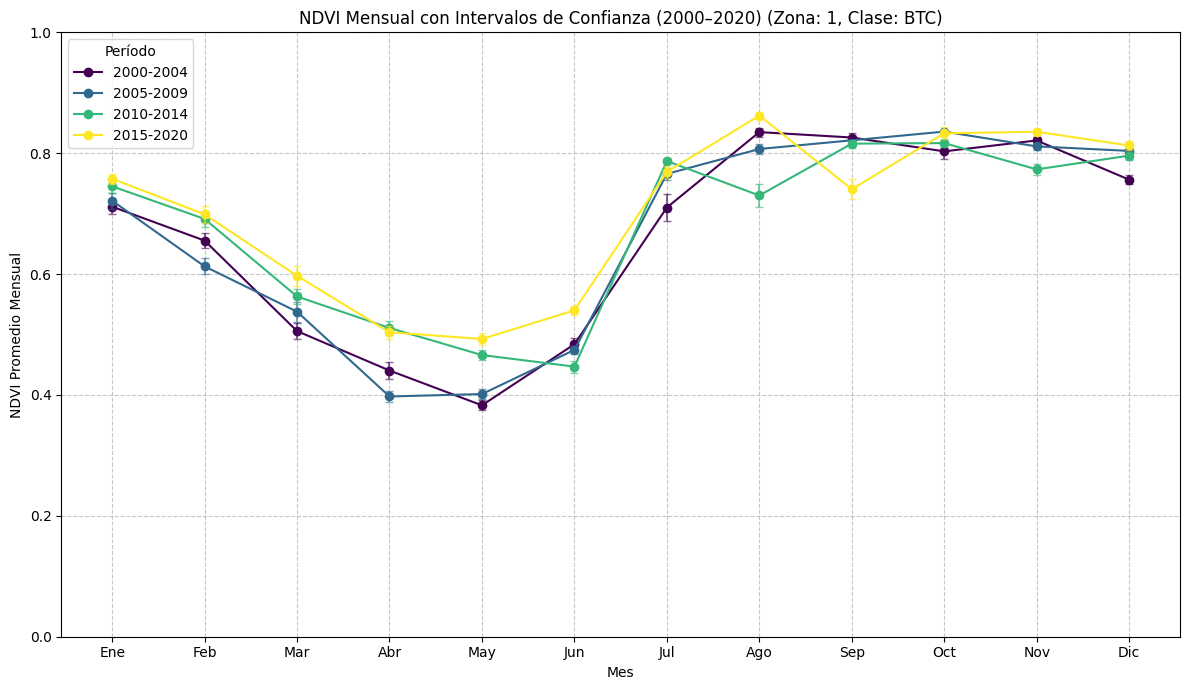

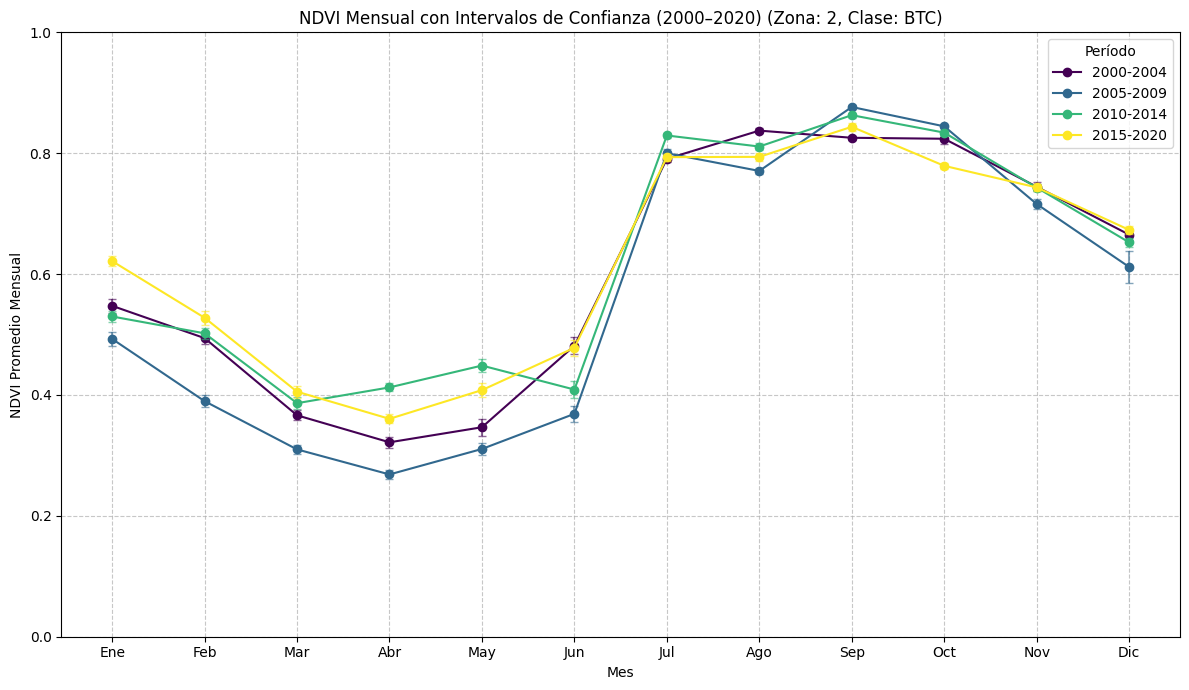

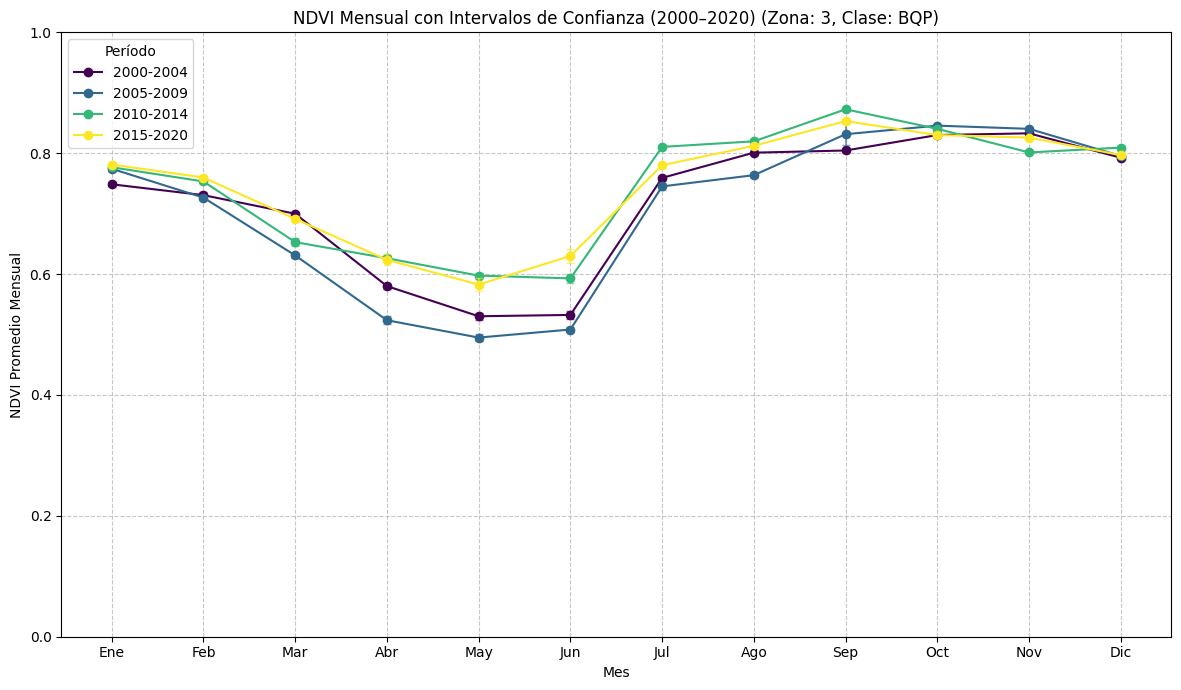

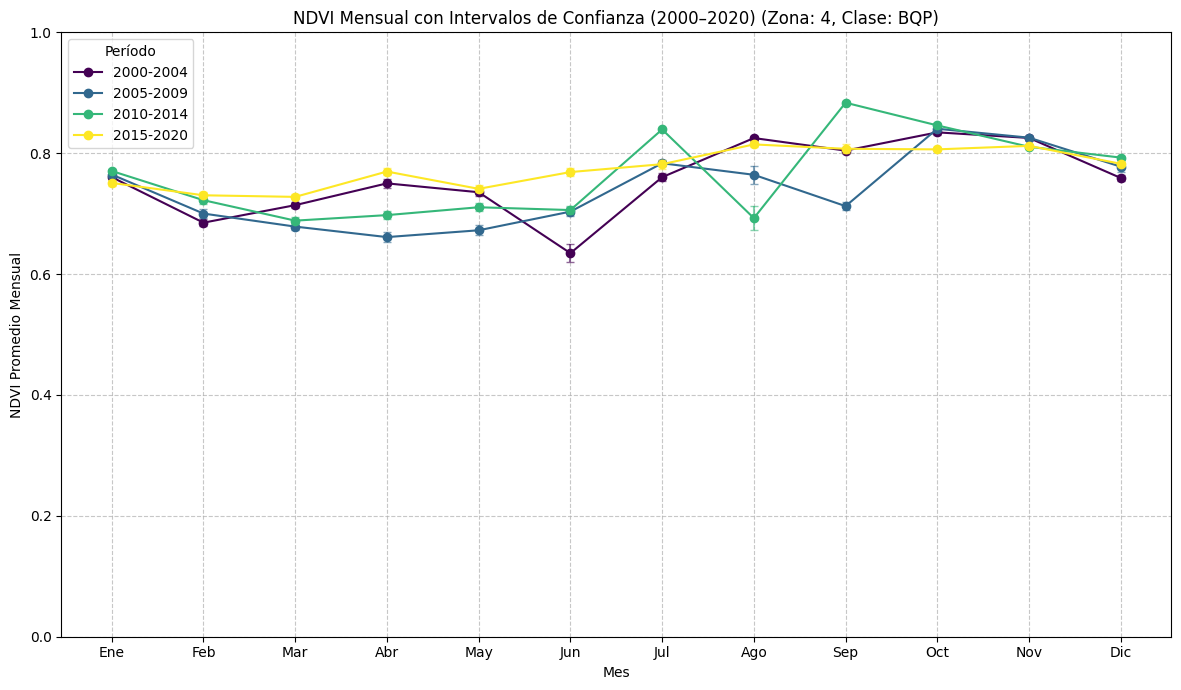

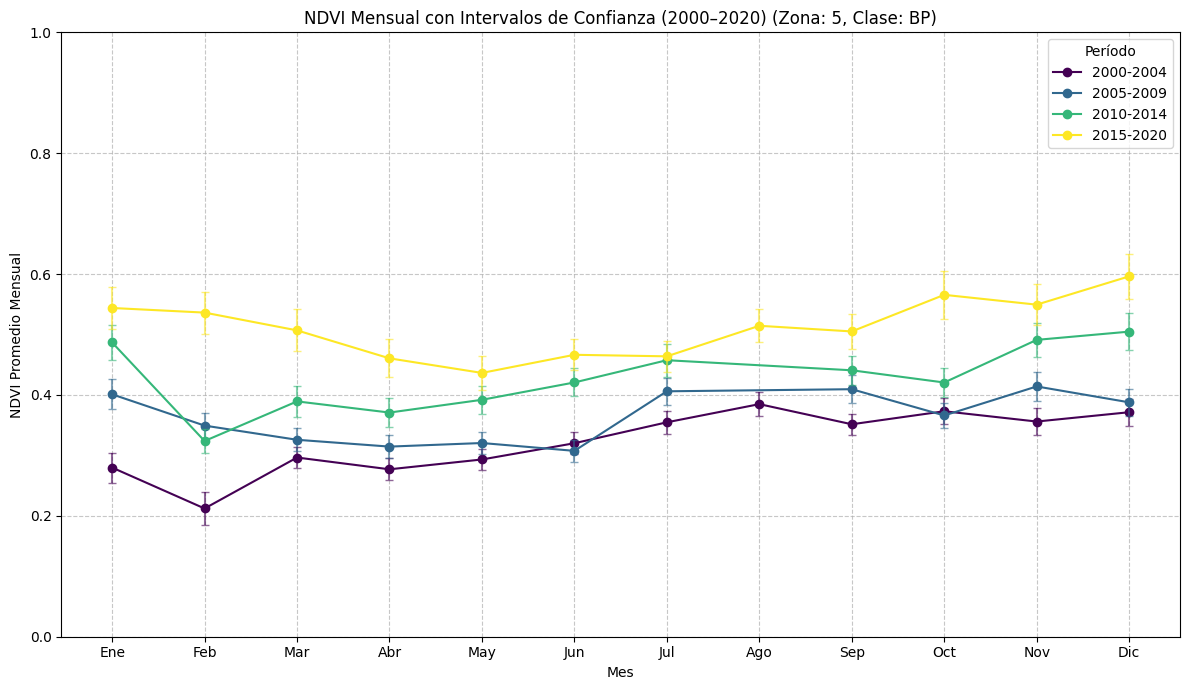

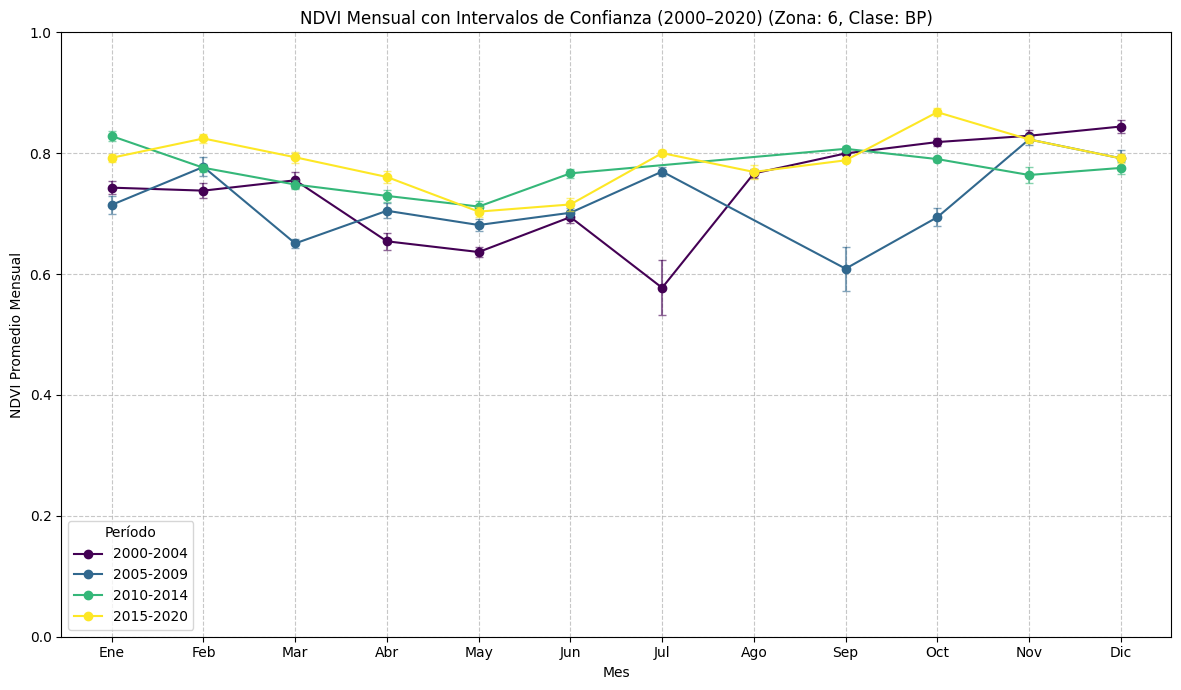

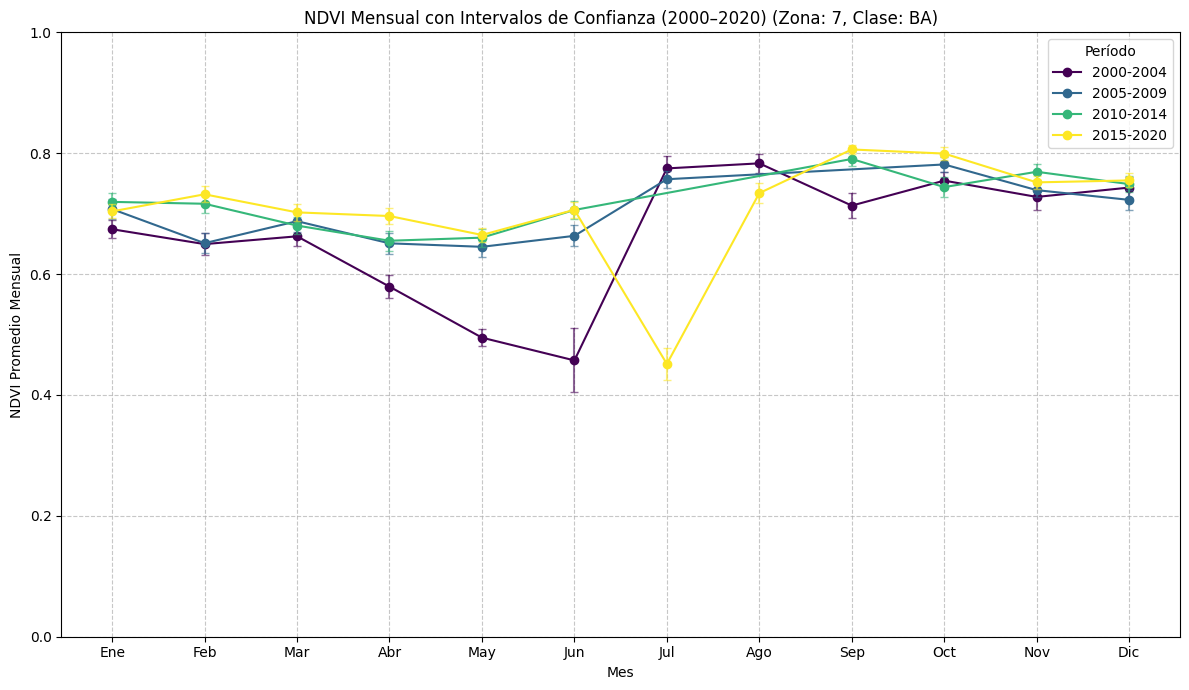

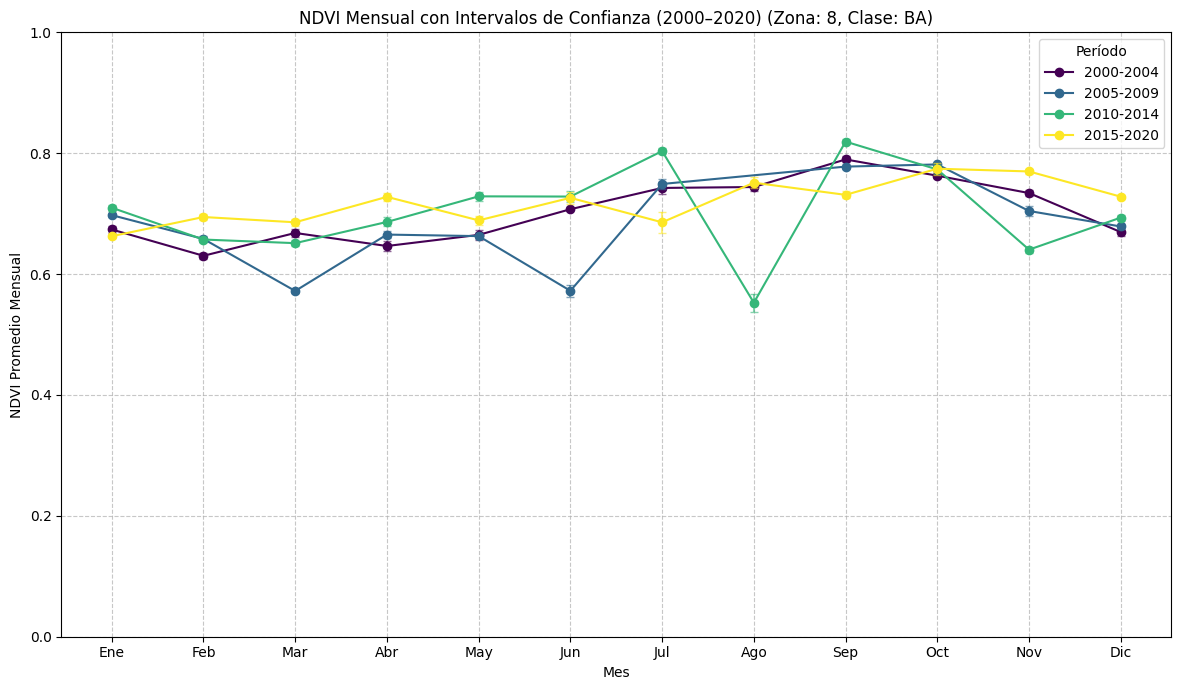

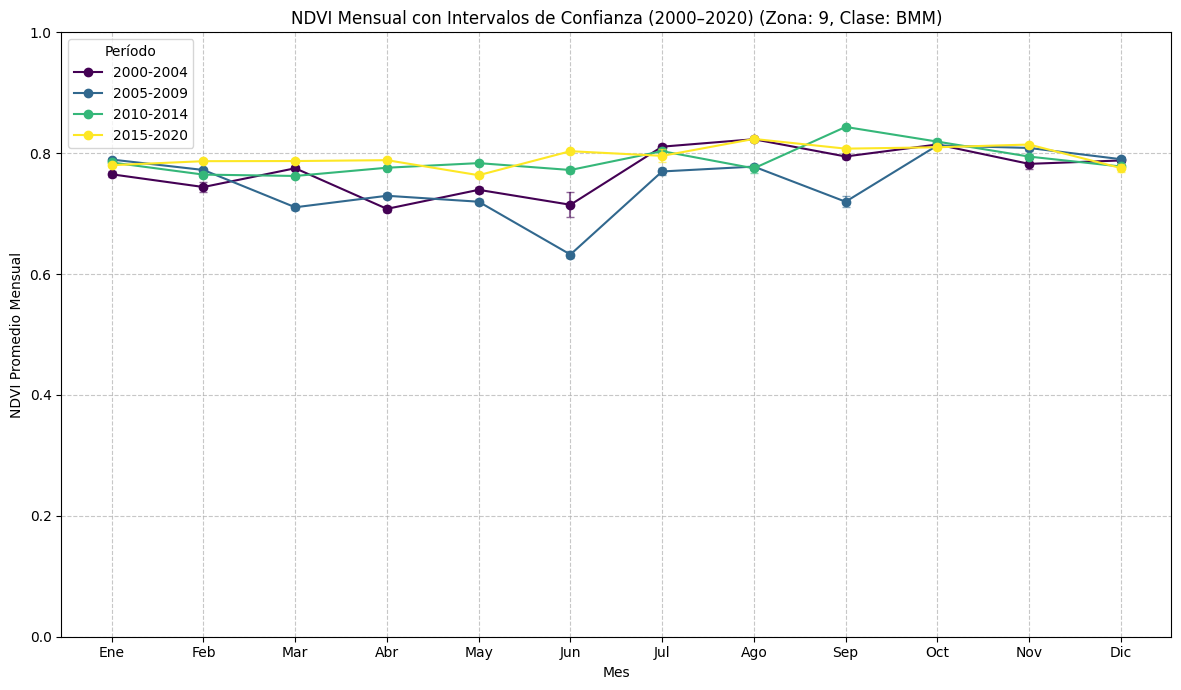

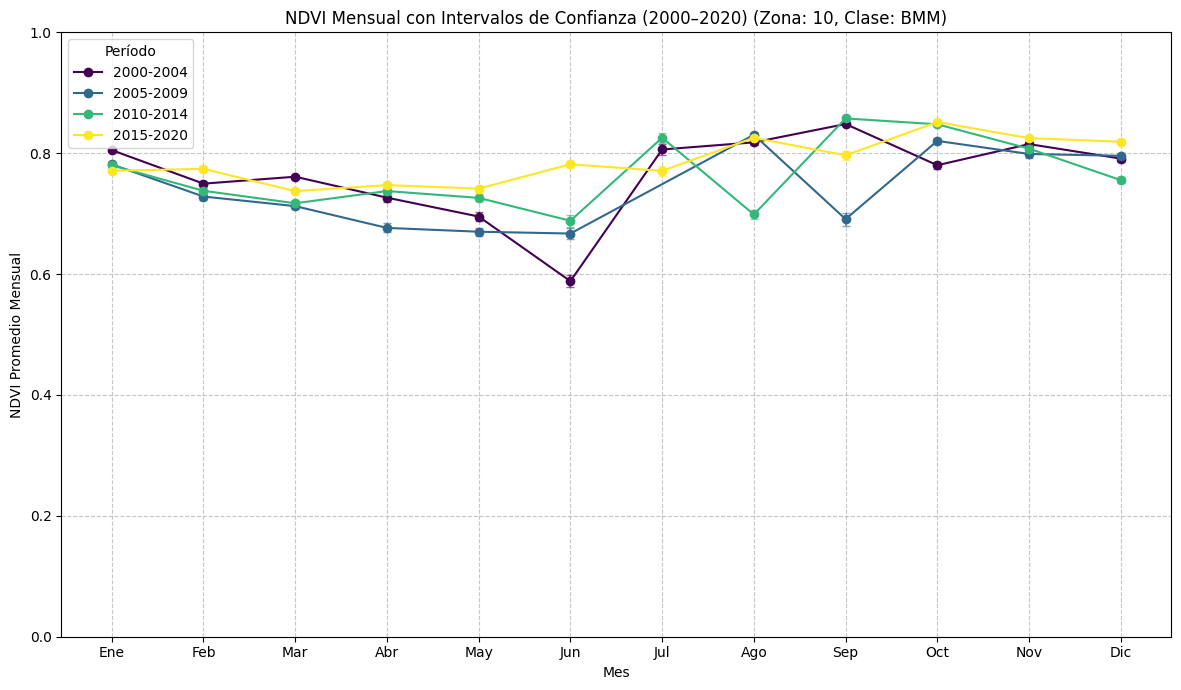

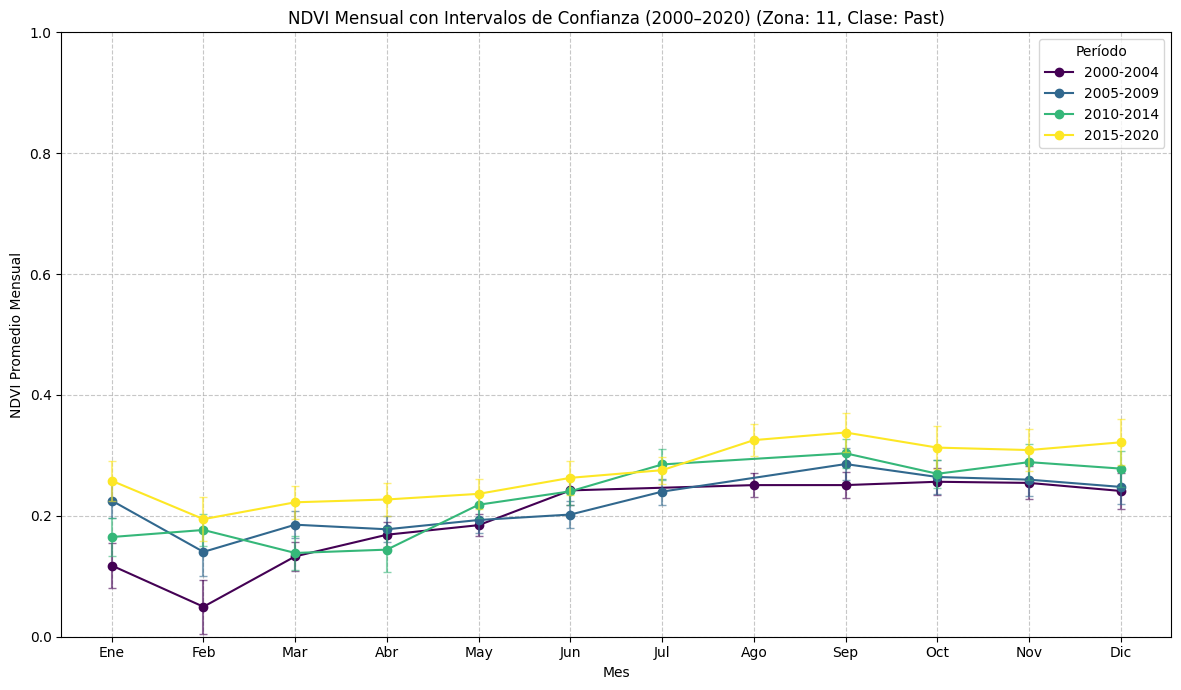

In [13]:
def graficar_ndvi_mensual(df, periods, title_suffix):
    plt.figure(figsize=(12, 7))
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    colores =plt.colormaps['viridis']

    for i, (period_name, _) in enumerate(periods.items()):
       period_df = df[df['period'] == period_name].sort_values(by='month')
       color = colores(i / (len(periods) - 1))  # Normalizado

       plt.plot(period_df['month'], period_df['mean'], marker='o', linestyle='-',
             label=period_name, color=color)

       plt.errorbar(period_df['month'], period_df['mean'],
                 yerr=[period_df['mean'] - period_df['lower_ci'],
                       period_df['upper_ci'] - period_df['mean']],
                 fmt='none', capsize=3, color=color, alpha=0.6)

    plt.xlabel('Mes')
    plt.ylabel('NDVI Promedio Mensual')
    plt.title(f'NDVI Mensual con Intervalos de Confianza (2000–2020) {title_suffix}')
    plt.xticks(range(1, 13), meses)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Período')
    plt.tight_layout()
    plt.ylim(0, 1)
    plt.show()

unique_polygons = df_mensual_poligonos_ic[['Identificador', 'Clase']].drop_duplicates().to_dict('records')

for polygon_info in unique_polygons:
    identificador = polygon_info['Identificador']
    clase = polygon_info['Clase']

    # Filtrar el DataFrame para el polígono actual
    df_polygon = df_mensual_poligonos_ic[
        (df_mensual_poligonos_ic['Identificador'] == identificador)
    ].copy()

    # Crear un título personalizado para cada gráfica
    title_suffix = f"(Zona: {identificador}, Clase: {clase})"

    # Graficar la dinámica mensual del NDVI para el polígono actual
    graficar_ndvi_mensual(df_polygon, periods, title_suffix=title_suffix)


### Guardar resultados en forma de CSV en Google Drive

In [14]:
# Definir las rutas de guardado
output_dir = RUTA_AOI # Usar la ruta definida para AOI

# Asegurarse de que el directorio de salida exista
os.makedirs(output_dir, exist_ok=True)

nombre_tabla_ndvi_anuales = f'{PREFIJO}_estadisticas_ndvi_anuales.csv'
nombre_tabla_ndvi_mensuales = f'{PREFIJO}_estadisticas_ndvi_mensuales.csv'

output_path_estadisticas_multiples = os.path.join(output_dir, nombre_tabla_ndvi_anuales)
output_path_df_mensual_poligonos_ic = os.path.join(output_dir, nombre_tabla_ndvi_mensuales)

# Guardar df_estadisticas_multiples
df_anual_ic.to_csv(output_path_estadisticas_multiples, index=False)
print(f"'estadisticas_multiples' guardado en: {output_path_estadisticas_multiples}")

# Guardar df_mensual_poligonos_ic
df_mensual_poligonos_ic.to_csv(output_path_df_mensual_poligonos_ic, index=False)
print(f"'df_mensual_poligonos_ic' guardado en: {output_path_df_mensual_poligonos_ic}")

'estadisticas_multiples' guardado en: /content/drive/MyDrive/Colab Data/Naylet/AOI/NCL_estadisticas_ndvi_anuales.csv
'df_mensual_poligonos_ic' guardado en: /content/drive/MyDrive/Colab Data/Naylet/AOI/NCL_estadisticas_ndvi_mensuales.csv
